# Jena Climate — Temperature Forecasting with Deep Learning
# Jena İklim — Derin Öğrenme ile Sıcaklık Tahmini

**EN —** In this notebook I build temperature forecasters on the Jena Climate dataset
(2009–2016, a weather station near Jena, Germany, sampled every 10 minutes).
The task I set myself: **look at the last 120 hours (5 days) of 14 weather variables and
predict the temperature exactly 24 hours after the end of that window.**

I train five models — a linear reference, an LSTM, a GRU, a 1D CNN and a Transformer —
but the point of this notebook is not the models. The point is the **baseline**.
On this dataset the naive rule *"the temperature in 24 hours will be the temperature right now"*
is famously hard to beat, and a model that cannot beat it has learned nothing useful.
So I compute that baseline **before** I train anything, and I judge every model against it.

**TR —** Bu notebook'ta Jena İklim veri seti üzerinde (2009–2016, Almanya'da Jena yakınlarındaki
bir istasyon, 10 dakikada bir örneklenmiş) sıcaklık tahmin modelleri kuruyorum.
Kendime koyduğum görev: **14 meteorolojik değişkenin son 120 saatine (5 gün) bakıp,
o pencerenin bitiminden tam 24 saat sonraki sıcaklığı tahmin etmek.**

Beş model eğitiyorum — doğrusal referans, LSTM, GRU, 1D CNN ve Transformer — ama bu
notebook'un derdi modeller değil. Derdi **baseline**.
Bu veri setinde *"24 saat sonraki sıcaklık, şu anki sıcaklıktır"* şeklindeki naif kuralı
geçmek meşhur şekilde zordur; bunu geçemeyen bir model işe yarar hiçbir şey öğrenmemiştir.
Bu yüzden o baseline'ı hiçbir şey eğitmeden **önce** hesaplıyorum ve her modeli ona karşı yargılıyorum.

---

### What I am careful about / Neye dikkat ediyorum

| | EN | TR |
|---|---|---|
| **Split** | Chronological, never random: train is the oldest block, test the newest. | Kronolojik, asla rastgele değil: train en eski blok, test en yeni blok. |
| **Scaling** | mean/std from the **train slice only**, then applied to val and test. | mean/std **yalnızca train diliminden**, sonra val ve test'e uygulanıyor. |
| **Windowing** | I split **first**, then window each slice **separately**, so no window crosses a boundary. | Önce **bölüyorum**, sonra her dilimi **ayrı ayrı** pencereliyorum; hiçbir pencere sınırı aşmıyor. |
| **Metrics** | MAE and RMSE, always converted back to **degrees Celsius**. | MAE ve RMSE, her zaman **derece cinsine** geri çevriliyor. |

## 1. Setup / Kurulum

**EN —** I keep all the real logic in `src/` and import it here. A notebook that contains
its own pipeline is a notebook that cannot be tested or reused; this one is a narrative
on top of code that lives in modules.

**TR —** Bütün gerçek mantığı `src/` içinde tutup buraya import ediyorum. Kendi hattını
içinde barındıran bir notebook, test edilemeyen ve tekrar kullanılamayan bir notebook'tur;
bu ise modüllerde yaşayan kodun üzerine anlatılan bir hikâye.

In [1]:
import sys
from pathlib import Path

# EN: make the project root importable no matter where Jupyter was started.
# TR: Jupyter nereden başlatılmış olursa olsun proje kökünü import edilebilir yap.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from src import config
from src.baselines import all_baselines, ClimatologyBaseline, persistence_metrics
from src.data import build_datasets, chronological_split, clean, load_raw, to_hourly
from src.evaluate import (
    compute_metrics,
    evaluate_model,
    plot_error_distribution,
    plot_history,
    plot_model_comparison,
    plot_predictions,
    plot_scatter,
    results_table,
)
from src.models import build_model, count_parameters, MODEL_REGISTRY
from src.train import get_device, set_seed, train_model

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 120)

set_seed(config.SEED)
print("project root:", PROJECT_ROOT)

project root: D:\jena-climate-forecasting


### 1.1 Which device am I actually on? / Gerçekten hangi cihazdayım?

**EN —** I print this explicitly rather than assuming. My card is a GTX 1050 Ti,
which is Pascal (`sm_61`); PyTorch's newer `cu128` wheels no longer compile for Pascal,
so this project installs the **CUDA 12.6** build. If the cell below says `cpu`,
the install went wrong — everything still runs, just slower.

**TR —** Bunu varsaymak yerine açıkça yazdırıyorum. Kartım GTX 1050 Ti, yani Pascal (`sm_61`);
PyTorch'un yeni `cu128` wheel'leri artık Pascal için derlenmiyor, bu yüzden bu proje
**CUDA 12.6** derlemesini kuruyor. Aşağıdaki hücre `cpu` diyorsa kurulum yanlış gitmiştir —
her şey yine çalışır, sadece yavaş.

In [2]:
device = get_device(verbose=True)

torch            : 2.7.1+cu126


device           : cuda


gpu              : NVIDIA GeForce GTX 1050 Ti
compute capability: sm_61
vram             : 4.0 GB
built for archs  : ['sm_50', 'sm_60', 'sm_61', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']


## 2. The raw data / Ham veri

**EN —** ~420,000 rows, one every 10 minutes for eight years, 14 variables.
`load_raw()` downloads and unzips the CSV on first call and parses the timestamps.

**TR —** ~420.000 satır, sekiz yıl boyunca 10 dakikada bir, 14 değişken.
`load_raw()` ilk çağrıda CSV'yi indirip açıyor ve zaman damgalarını ayrıştırıyor.

In [3]:
raw = load_raw()
print(f"shape: {raw.shape}")
print(f"range: {raw.index.min()}  ->  {raw.index.max()}")
raw.head()

shape: (420551, 14)
range: 2009-01-01 00:10:00  ->  2017-01-01 00:00:00


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [4]:
raw.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
p (mbar),989.212776,8.358481,913.60,1015.35
T (degC),9.450147,8.423365,-23.01,37.28
Tpot (K),283.492743,8.504471,250.60,311.34
Tdew (degC),4.955854,6.730674,-25.01,23.11
rh (%),76.008259,16.476175,12.95,100.00
VPmax (mbar),13.576251,7.739020,0.95,63.77
VPact (mbar),9.533756,4.184164,0.79,28.32
VPdef (mbar),4.042412,4.896851,0.00,46.01
sh (g/kg),6.022408,2.656139,0.50,18.13
H2OC (mmol/mol),9.640223,4.235395,0.80,28.82


### 2.1 Two defects I found by looking / Bakarak bulduğum iki kusur

**EN —** I did not take this file on trust. Two things are wrong with it:

1. **`-9999.0` sentinels.** The wind columns use `-9999.0` to mean "the sensor failed"
   instead of leaving the cell empty. Look at the `min` for `wv (m/s)` above. A single one of
   these would drag the column mean and std far off and quietly poison normalisation.
2. **Duplicated and missing timestamps.** 327 timestamps appear twice — the days
   01–02.07.2010 and 20–21.03.2014 are recorded twice — and several hundred 10-minute steps
   are missing entirely. So the series is **not** on a regular grid out of the box,
   which matters enormously when every model assumes a fixed time step between rows.

**TR —** Bu dosyaya güvenmedim. İki şey bozuk:

1. **`-9999.0` sentinel değerleri.** Rüzgâr sütunları, hücreyi boş bırakmak yerine
   "sensör arızalandı" demek için `-9999.0` kullanıyor. Yukarıdaki `wv (m/s)` min değerine bak.
   Bunlardan bir tanesi bile sütun ortalamasını ve std'sini çok uzağa çeker ve normalizasyonu
   sessizce zehirler.
2. **Tekrar eden ve eksik zaman damgaları.** 327 zaman damgası iki kez geçiyor — 01–02.07.2010
   ve 20–21.03.2014 günleri çift kaydedilmiş — ve birkaç yüz 10-dakikalık adım hiç yok.
   Yani seri kutudan çıktığı haliyle düzenli bir ızgarada **değil**; her model satırlar arasında
   sabit zaman adımı varsaydığı için bu son derece önemli.

In [5]:
# EN: evidence for defect 1 / TR: 1. kusurun kanıtı
for col in config.SENTINEL_COLS:
    n = int((raw[col] <= config.SENTINEL_VALUE).sum())
    print(f"{col:<16} {n:>3} sentinel cells, min = {raw[col].min():.2f}")

# EN: evidence for defect 2 / TR: 2. kusurun kanıtı
dups = raw.index.duplicated(keep="first")
print(f"\nduplicated timestamps: {dups.sum()}")
print("affected days:", sorted({d.date() for d in raw.index[dups]}))

expected = pd.date_range(raw.index.min(), raw.index.max(), freq="10min")
print(f"expected 10-min steps: {len(expected):,}")
print(f"unique timestamps    : {raw.index.nunique():,}")
print(f"missing steps        : {len(expected) - raw.index.nunique():,}")

wv (m/s)          18 sentinel cells, min = -9999.00
max. wv (m/s)     20 sentinel cells, min = -9999.00

duplicated timestamps: 327
affected days: [datetime.date(2010, 7, 1), datetime.date(2010, 7, 2), datetime.date(2014, 3, 20), datetime.date(2014, 3, 21)]
expected 10-min steps: 420,768
unique timestamps    : 420,224
missing steps        : 544


### 2.2 Cleaning / Temizleme

**EN —** `clean()` fixes both defects: sentinels become NaN, duplicates are dropped
(keeping the first occurrence), the series is reindexed onto a complete 10-minute grid so
gaps become explicit NaNs, and then everything is interpolated **in time**.
Then I down-sample to hourly by taking the readings on the hour — I take an instantaneous
reading rather than an hourly average, because the target is an instantaneous measurement.

**TR —** `clean()` iki kusuru da gideriyor: sentinel değerler NaN'e dönüyor, tekrarlar
(ilki tutularak) atılıyor, seri eksiksiz bir 10 dakikalık ızgaraya yeniden indeksleniyor ki
boşluklar açık NaN hâline gelsin, sonra her şey **zamana göre** interpole ediliyor.
Ardından tam saat ölçümlerini alarak saatliğe seyreltiyorum — saatlik ortalama değil anlık
ölçüm alıyorum, çünkü hedef anlık bir ölçüm.

In [6]:
cleaned, report = clean(raw)
print(report.summary())

# EN: drop the internal "this row was invented" flag - it is bookkeeping, not a feature.
# TR: "bu satır uydurma" iç işaretini at - bu bir öznitelik değil, kayıt tutma.
hourly = to_hourly(cleaned).drop(columns=[config.SYNTHETIC_COL])
print(f"\nhourly shape: {hourly.shape}")
print(f"step check  : {hourly.index.to_series().diff().value_counts().head(3).to_dict()}")

rows in .................. 420,551
rows out ................. 420,768
duplicate timestamps ..... 327 (dropped)
sentinel (-9999) cells ... {'wv (m/s)': 18, 'max. wv (m/s)': 20} (interpolated)
missing grid steps ....... 544 (interpolated)
longest contiguous gap ... 445 steps (~74.2 h)

hourly shape: (70128, 14)
step check  : {Timedelta('0 days 01:00:00'): 70127}


### 2.3 The gap that actually matters / Asıl önemli olan boşluk

**EN —** "Interpolated 544 missing steps" sounds harmless until I look at *where* they are.
Most of the gaps are one or two steps, but **one of them is 74 hours long — 25–28 October 2016 —
and October 2016 is inside my test slice.**

Interpolating across three days of weather does not recover the weather; it invents a straight
line. And a straight line is *trivially* easy for the persistence baseline to predict, which means
those hours would flatter every score I report. Scoring a model on fabricated targets is not an
honest test.

So `WindowDataset` flags every synthetic row and drops any window that **reads** one or
**predicts** one. It costs me ~1.6% of the test windows. That is the right price.

**TR —** "544 eksik adım interpole edildi" cümlesi, o adımların *nerede* olduğuna bakana kadar
masum duruyor. Boşlukların çoğu bir iki adımlık, ama **bir tanesi 74 saat uzunluğunda —
25–28 Ekim 2016 — ve Ekim 2016 benim test dilimimin içinde.**

Üç günlük havayı interpole etmek havayı geri getirmez; düz bir çizgi uydurur. Düz bir çizgiyi
tahmin etmek ise persistence baseline'ı için *çocuk oyuncağıdır*; yani o saatler raporladığım her
skoru olduğundan iyi gösterirdi. Uydurulmuş hedefler üzerinden model puanlamak dürüst bir sınav
değildir.

Bu yüzden `WindowDataset` her sentetik satırı işaretliyor ve böyle bir satırı **okuyan** ya da
**tahmin eden** her pencereyi atıyor. Bana test pencerelerinin ~%1.6'sına mal oluyor.
Ödenmesi gereken doğru bedel bu.

In [7]:
# EN: where are the gaps, and how long? / TR: boşluklar nerede ve ne kadar uzun?
deduped = raw[~raw.index.duplicated(keep="first")]
full_grid = pd.date_range(deduped.index.min(), deduped.index.max(), freq="10min")
missing = pd.Series(full_grid.difference(deduped.index))

blocks = missing.groupby((missing.diff() != pd.Timedelta("10min")).cumsum())
gaps = blocks.agg(["min", "max", "count"]).sort_values("count", ascending=False)

print("Gaps in the raw series / Ham serideki boşluklar:")
for _, g in gaps.iterrows():
    print(f"  {g['min']}  ->  {g['max']}   {g['count']:>4} steps (~{g['count'] * 10 / 60:.1f} h)")

# EN: the honest comparison - with and without the invented windows.
# TR: dürüst karşılaştırma - uydurulmuş pencerelerle ve onlarsız.
strict = build_datasets()
loose = build_datasets(exclude_interpolated=False)
for split in ("train", "val", "test"):
    s, l = getattr(strict, split), getattr(loose, split)
    ms, _ = persistence_metrics(s)
    ml, _ = persistence_metrics(l)
    print(f"\n{split}: kept {len(s):,} of {len(l):,} windows (dropped {s.n_dropped:,})")
    print(f"  persistence MAE  {ms.mae:.4f} °C (honest)  vs  {ml.mae:.4f} °C (with invented hours)")

Gaps in the raw series / Ham serideki boşluklar:
  2016-10-25 10:40:00  ->  2016-10-28 12:40:00    445 steps (~74.2 h)
  2014-09-24 17:10:00  ->  2014-09-25 08:50:00     95 steps (~15.8 h)
  2009-10-08 09:50:00  ->  2009-10-08 10:00:00      2 steps (~0.3 h)
  2014-07-30 08:10:00  ->  2014-07-30 08:10:00      1 steps (~0.2 h)
  2013-05-16 09:00:00  ->  2013-05-16 09:00:00      1 steps (~0.2 h)



train: kept 41,691 of 41,933 windows (dropped 242)
  persistence MAE  2.6304 °C (honest)  vs  2.6298 °C (with invented hours)

val: kept 13,733 of 13,882 windows (dropped 149)
  persistence MAE  2.5553 °C (honest)  vs  2.5583 °C (with invented hours)

test: kept 13,667 of 13,884 windows (dropped 217)
  persistence MAE  2.5746 °C (honest)  vs  2.5646 °C (with invented hours)


**EN —** The invented hours made the task look *easier*, exactly as I expected: a linear
interpolation is almost perfectly predictable by "same as now". Removing them raises the test
baseline slightly, and that slightly harder number is the one I will hold every model to.

**TR —** Uydurulmuş saatler görevi tam beklediğim gibi *daha kolay* gösteriyormuş: doğrusal bir
interpolasyon "şu anki değerle aynı" kuralıyla neredeyse kusursuz tahmin edilir. Onları çıkarmak
test baseline'ını biraz yükseltiyor ve her modeli tutacağım sayı, o birazcık daha zor olan sayı.

## 3. EDA / Keşifsel veri analizi

**EN —** Before modelling I want to know what the signal actually looks like.
Three things matter for this task: the yearly cycle, the daily cycle, and how much of the
other 13 variables is just temperature wearing a hat.

**TR —** Modellemeden önce sinyalin gerçekte neye benzediğini bilmek istiyorum.
Bu görev için üç şey önemli: yıllık döngü, günlük döngü ve diğer 13 değişkenin ne kadarının
aslında şapka takmış sıcaklık olduğu.

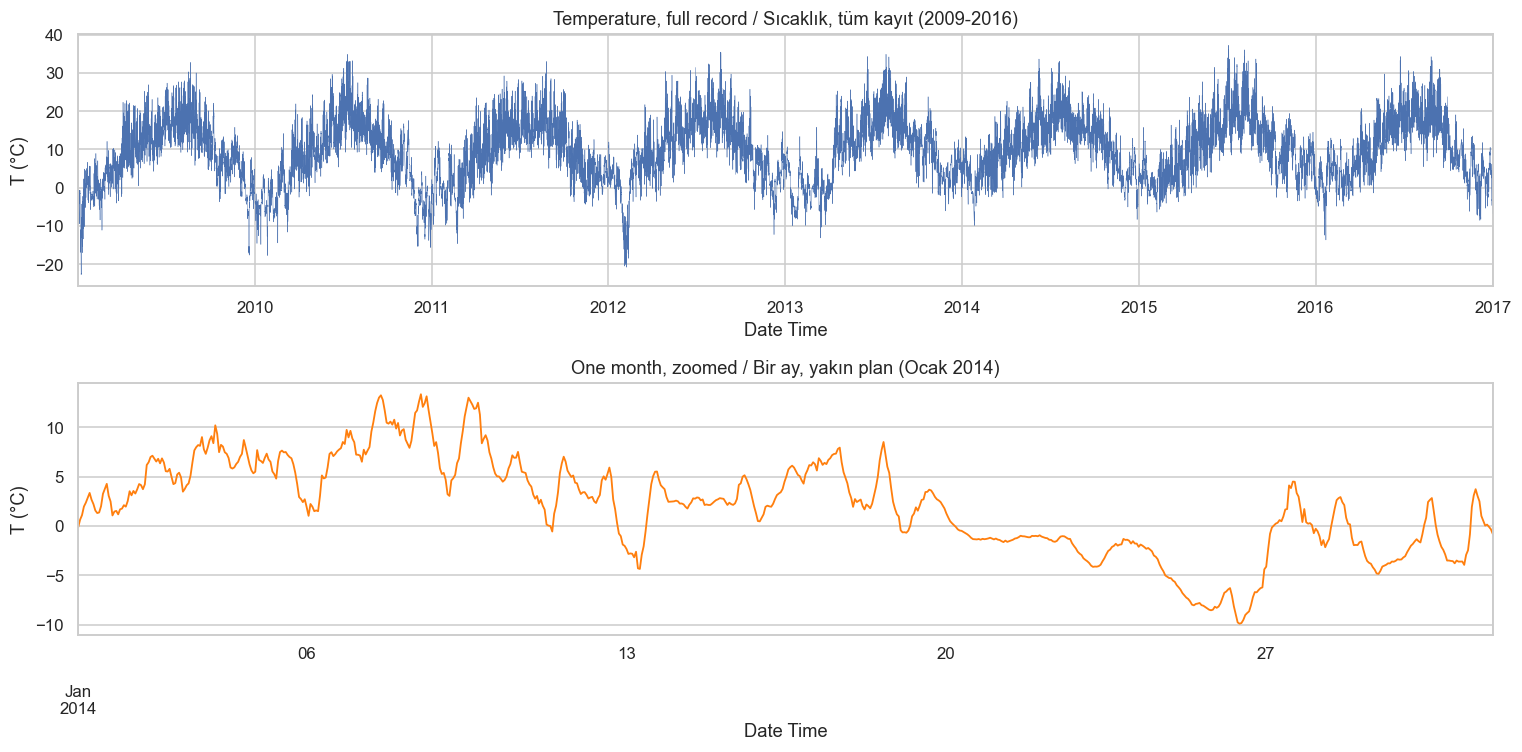

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
hourly[config.TARGET_COL].plot(ax=axes[0], lw=0.3)
axes[0].set_title("Temperature, full record / Sıcaklık, tüm kayıt (2009-2016)")
axes[0].set_ylabel("T (°C)")

window = hourly.loc["2014-01-01":"2014-01-31", config.TARGET_COL]
window.plot(ax=axes[1], lw=1.2, color="tab:orange")
axes[1].set_title("One month, zoomed / Bir ay, yakın plan (Ocak 2014)")
axes[1].set_ylabel("T (°C)")
plt.tight_layout()
plt.show()

**EN —** The top panel is the whole story of this dataset in one picture: an enormous,
almost perfectly regular yearly cycle. That is *why* the persistence baseline is so strong —
over 24 hours the seasonal signal barely moves, so "today's temperature" is already a very
good guess for tomorrow's. What is left for a model to learn is the weather *on top of*
the season, and that part is genuinely hard.

**TR —** Üstteki panel bu veri setinin bütün hikâyesini tek resimde anlatıyor: devasa ve
neredeyse kusursuz düzenli bir yıllık döngü. Persistence baseline'ının bu kadar güçlü olmasının
*sebebi* bu — 24 saat içinde mevsimsel sinyal neredeyse hiç kıpırdamıyor, dolayısıyla "bugünün
sıcaklığı" yarın için zaten çok iyi bir tahmin. Modele kalan, mevsimin *üstündeki* hava
durumunu öğrenmek ve o kısım gerçekten zor.

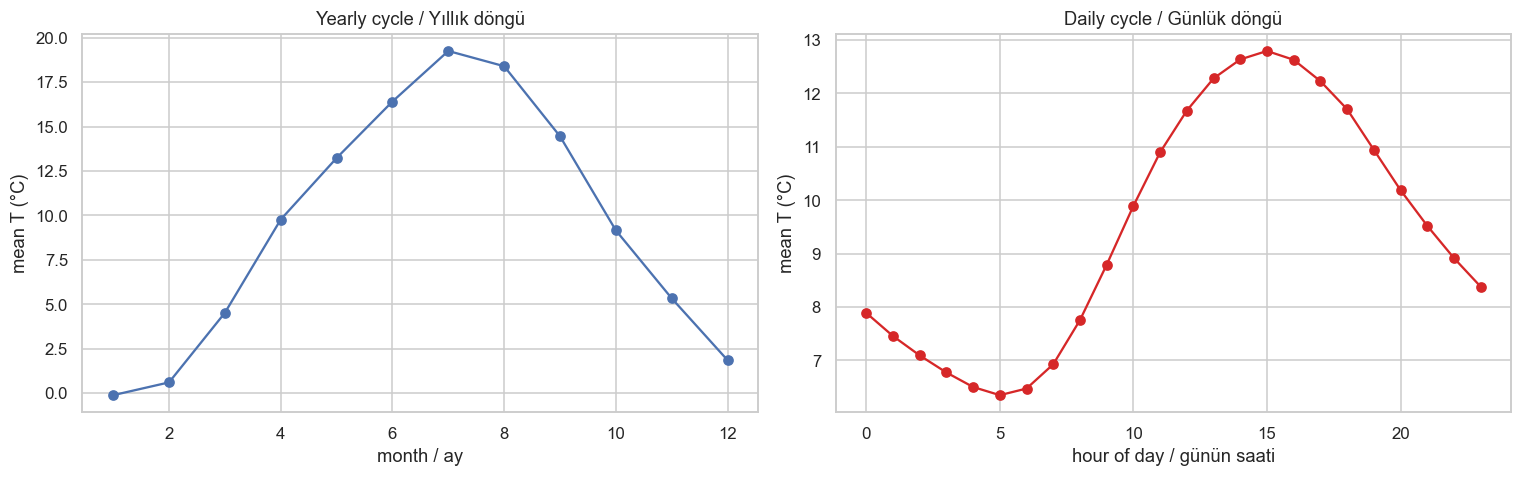

yearly swing / yıllık salınım: 19.4 °C
daily swing  / günlük salınım: 6.4 °C


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

by_month = hourly.groupby(hourly.index.month)[config.TARGET_COL].mean()
axes[0].plot(by_month.index, by_month.values, marker="o")
axes[0].set_xlabel("month / ay")
axes[0].set_ylabel("mean T (°C)")
axes[0].set_title("Yearly cycle / Yıllık döngü")

by_hour = hourly.groupby(hourly.index.hour)[config.TARGET_COL].mean()
axes[1].plot(by_hour.index, by_hour.values, marker="o", color="tab:red")
axes[1].set_xlabel("hour of day / günün saati")
axes[1].set_ylabel("mean T (°C)")
axes[1].set_title("Daily cycle / Günlük döngü")
plt.tight_layout()
plt.show()

print(f"yearly swing / yıllık salınım: {by_month.max() - by_month.min():.1f} °C")
print(f"daily swing  / günlük salınım: {by_hour.max() - by_hour.min():.1f} °C")

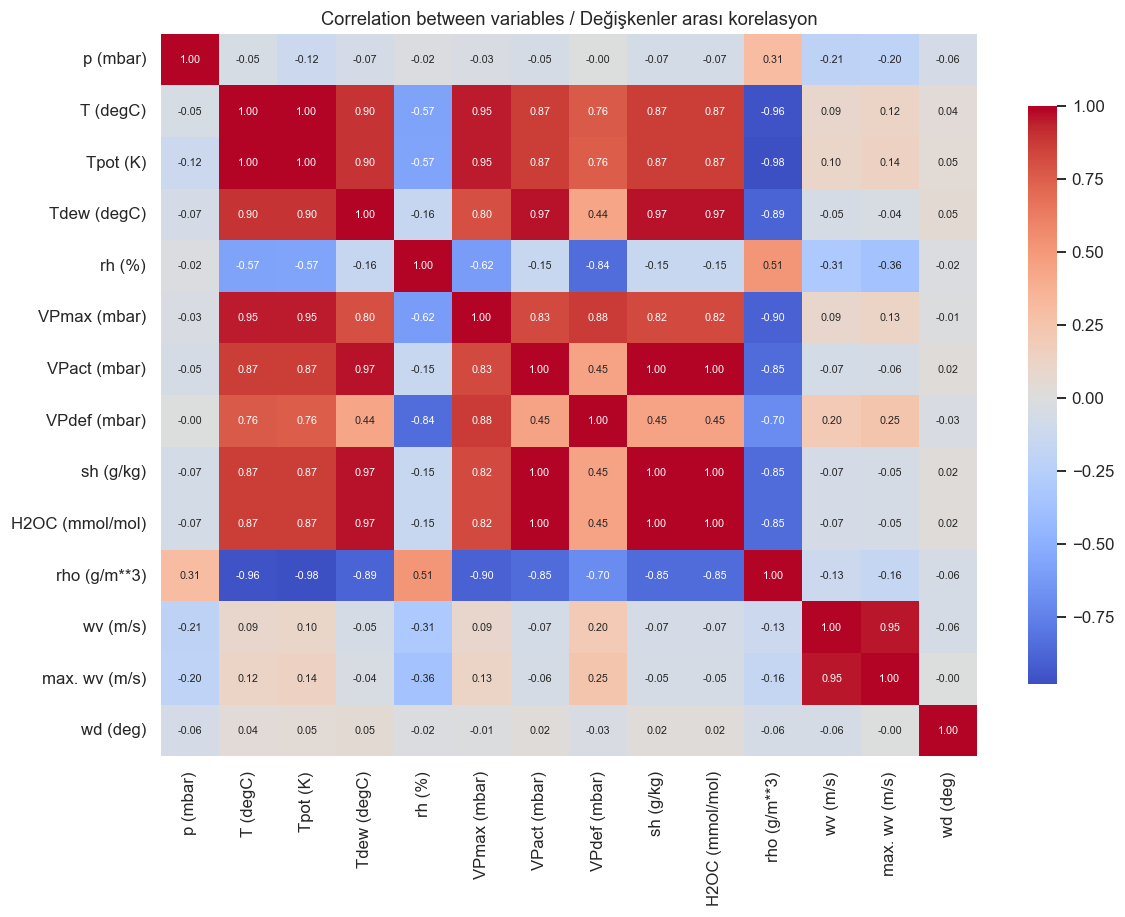

Most correlated with the target / Hedefle en ilişkili:
Tpot (K)           0.996817
rho (g/m**3)       0.963327
VPmax (mbar)       0.951059
Tdew (degC)        0.895953
VPact (mbar)       0.867994
H2OC (mmol/mol)    0.867498
Name: T (degC), dtype: float64


In [10]:
fig, ax = plt.subplots(figsize=(11, 8.5))
corr = hourly.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation between variables / Değişkenler arası korelasyon")
plt.tight_layout()
plt.show()

print("Most correlated with the target / Hedefle en ilişkili:")
print(corr[config.TARGET_COL].drop(config.TARGET_COL).abs().sort_values(ascending=False).head(6))

**EN —** `Tpot (K)` is temperature in Kelvin and `Tdew`, `VPmax`, `rho` are all near-deterministic
functions of it, so several "extra" variables carry almost no new information. I keep them
anyway — I would rather let the network decide what is useful than hand-pick features on a
hunch — but this is worth knowing when I later ask whether the multivariate input actually earned
its keep.

**TR —** `Tpot (K)` zaten Kelvin cinsinden sıcaklık; `Tdew`, `VPmax`, `rho` ise neredeyse
deterministik olarak ona bağlı. Yani birkaç "ek" değişken neredeyse hiç yeni bilgi taşımıyor.
Yine de hepsini tutuyorum — neyin işe yaradığına sezgiyle ben karar vermektense ağın karar
vermesini tercih ederim — ama ileride çok değişkenli girdinin ekmeğini gerçekten hak edip
etmediğini sorgularken bunu akılda tutmak gerek.

## 4. Framing the task / Görevin kurgusu

**EN —** One sample is:

- **input**: hours `t-119 … t`, all 14 variables, standardised → shape `(120, 14)`
- **target**: the temperature at hour `t+24`, a single number

So the model never sees anything after `t`, and the thing it predicts is a full day beyond its
last observation. This is the same framing Chollet uses, which lets me sanity-check my numbers
against a published reference.

**TR —** Bir örnek şu:

- **girdi**: `t-119 … t` saatleri, 14 değişkenin tamamı, standartlaştırılmış → boyut `(120, 14)`
- **hedef**: `t+24` saatindeki sıcaklık, tek bir sayı

Yani model `t`'den sonrasını asla görmüyor ve tahmin ettiği şey son gözleminden tam bir gün
ötede. Bu, Chollet'in kullandığı kurgunun aynısı; böylece sayılarımı yayımlanmış bir referansla
karşılaştırıp kontrol edebiliyorum.

### 4.1 The split, and why windows come after it / Bölme ve pencerelerin neden sonra geldiği

**EN —** This is the part most tutorials get wrong. If you window the whole series first and
then split by sample index, a validation window whose input starts before the split boundary
contains training timesteps — the model has already been trained on the exact hours it is being
validated on. It is a small leak, but it is a real one, and it flatters the numbers.

I do the opposite: **split the dataframe into three contiguous blocks first, then build windows
inside each block independently.** The cost is that I lose `lookback + horizon` samples at each
boundary. That is the correct price to pay.

**TR —** Çoğu eğitim materyalinin yanlış yaptığı kısım burası. Önce tüm seriyi pencereleyip
sonra örnek indeksine göre bölersen, girdisi bölme sınırından önce başlayan bir validation
penceresi eğitim adımlarını içerir — model, üzerinde doğrulandığı saatlerle zaten eğitilmiştir.
Küçük bir sızıntı ama gerçek bir sızıntı ve sayıları olduğundan iyi gösteriyor.

Ben tersini yapıyorum: **önce dataframe'i üç bitişik bloğa bölüyorum, sonra her blok içinde
pencereleri bağımsız kuruyorum.** Bedeli, her sınırda `lookback + horizon` kadar örnek kaybetmek.
Ödenmesi gereken doğru bedel bu.

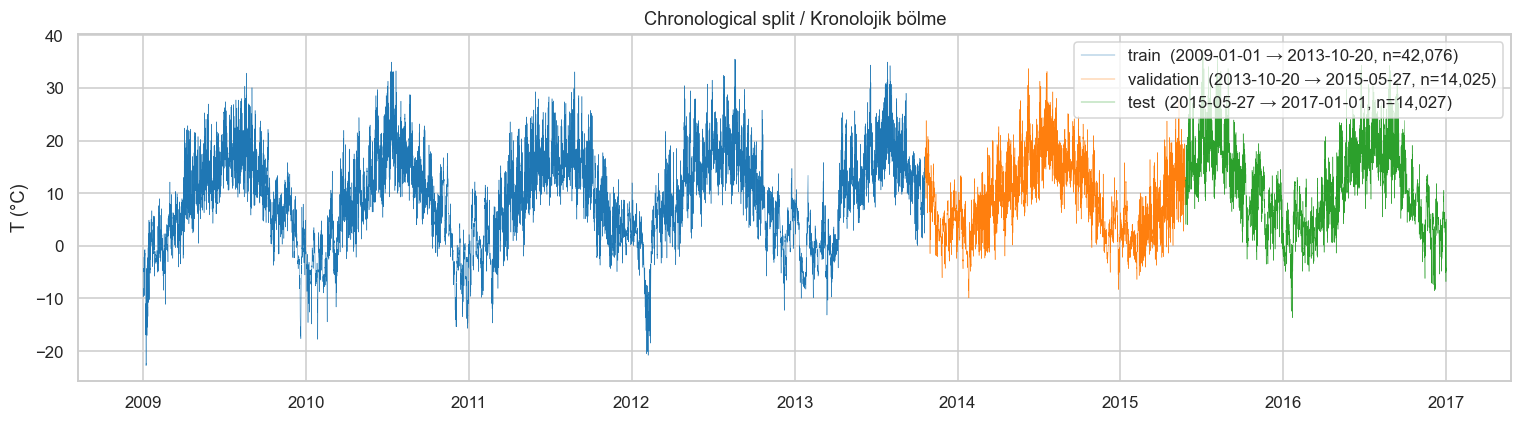

In [11]:
train_df, val_df, test_df = chronological_split(hourly)

fig, ax = plt.subplots(figsize=(14, 4))
for part, name, color in (
    (train_df, "train", "tab:blue"),
    (val_df, "validation", "tab:orange"),
    (test_df, "test", "tab:green"),
):
    ax.plot(part.index, part[config.TARGET_COL], lw=0.3, color=color,
            label=f"{name}  ({part.index.min().date()} → {part.index.max().date()}, n={len(part):,})")
ax.set_title("Chronological split / Kronolojik bölme")
ax.set_ylabel("T (°C)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 4.2 Normalisation from the train slice only / Normalizasyon yalnızca train diliminden

**EN —** The other classic leak. If I compute mean and std over the whole frame, information
about 2016 (the test years) is baked into the numbers the model trains on. So I fit the
statistics on train and only *apply* them to validation and test.

**TR —** Diğer klasik sızıntı. Ortalama ve std'yi tüm veri üzerinden hesaplarsam, 2016'ya
(test yıllarına) dair bilgi modelin eğitildiği sayılara işlenmiş olur. Bu yüzden istatistikleri
train üzerinde fit edip validation ve test'e yalnızca *uyguluyorum*.

In [12]:
bundle = build_datasets(use_engineered_features=False)

print(bundle.summary())
print()
print(f"target mean (train only) : {bundle.normalizer.target_mean:.3f} °C")
print(f"target std  (train only) : {bundle.normalizer.target_std:.3f} °C")
print()
print("Proof the stats came from train only / İstatistiklerin yalnızca train'den geldiğinin kanıtı:")
print(f"  train mean of T : {train_df[config.TARGET_COL].mean():.3f} °C  <- used")
print(f"  whole-set mean  : {hourly[config.TARGET_COL].mean():.3f} °C  <- NOT used")

x, y = bundle.train[0]
print(f"\none sample: x {tuple(x.shape)}  ->  y {tuple(y.shape)} (scalar, standardised)")

features (14): p (mbar), T (degC), Tpot (K), Tdew (degC), rh (%), VPmax (mbar), VPact (mbar), VPdef (mbar), sh (g/kg), H2OC (mmol/mol), rho (g/m**3), wv (m/s), max. wv (m/s), wd (deg)
lookback / horizon: 120 h / 24 h
train windows= 41,691  (dropped  242 touching interpolated data)  2009-01-01 -> 2013-10-20
val   windows= 13,733  (dropped  149 touching interpolated data)  2013-10-20 -> 2015-05-27
test  windows= 13,667  (dropped  217 touching interpolated data)  2015-05-27 -> 2017-01-01

target mean (train only) : 8.995 °C
target std  (train only) : 8.826 °C

Proof the stats came from train only / İstatistiklerin yalnızca train'den geldiğinin kanıtı:
  train mean of T : 8.995 °C  <- used
  whole-set mean  : 9.444 °C  <- NOT used

one sample: x (120, 14)  ->  y () (scalar, standardised)


## 5. The baselines / Sağduyu referansları

**EN —** Now the honest part, and I do it **before** training anything so I cannot grade the
models on a curve afterwards. Three references:

1. **Persistence** — "the temperature in 24 hours is the temperature now". No parameters,
   nothing to overfit. **This is the number to beat.**
2. **TrainMean** — always predict the average training temperature. The weakest sensible
   reference; if a model cannot beat this, the pipeline is broken, not the architecture.
3. **Climatology** — the average temperature for this (month, hour) cell, learned from train.
   It knows July is warmer than January but nothing about today's weather. It tells me how
   much of a model's skill is *just* "learning the seasons".

**TR —** Şimdi dürüst kısım; hiçbir şey eğitmeden **önce** yapıyorum ki sonradan modelleri
kayıramayayım. Üç referans:

1. **Persistence** — "24 saat sonraki sıcaklık, şu anki sıcaklıktır". Parametre yok,
   overfit edecek bir şey yok. **Geçilmesi gereken sayı bu.**
2. **TrainMean** — her zaman eğitim ortalamasını tahmin et. En zayıf makul referans;
   bir model bunu bile geçemiyorsa sorun mimaride değil hattın kendisindedir.
3. **Climatology** — train'den öğrenilmiş (ay, saat) hücresinin ortalama sıcaklığı.
   Temmuzun ocaktan sıcak olduğunu biliyor ama bugünkü havadan haberi yok. Bir modelin
   başarısının ne kadarının *sadece* "mevsimleri öğrenmek" olduğunu söylüyor.

In [13]:
results, test_predictions = all_baselines(bundle)

for name, splits in results.items():
    print(f"{name:<14} val  {splits['val']}")
    print(f"{'':<14} test {splits['test']}")

BASELINE_MAE = results["Persistence"]["test"].mae
print(f"\n>>> Every model has to beat {BASELINE_MAE:.3f} °C test MAE. <<<")
print(f">>> Her modelin geçmesi gereken eşik: {BASELINE_MAE:.3f} °C test MAE. <<<")

Persistence    val  MAE 2.555 C | RMSE 3.299 C | n=13,733
               test MAE 2.575 C | RMSE 3.368 C | n=13,667
TrainMean      val  MAE 5.898 C | RMSE 7.125 C | n=13,733
               test MAE 6.922 C | RMSE 8.491 C | n=13,667
Climatology    val  MAE 3.651 C | RMSE 4.565 C | n=13,733
               test MAE 3.712 C | RMSE 4.686 C | n=13,667

>>> Every model has to beat 2.575 °C test MAE. <<<
>>> Her modelin geçmesi gereken eşik: 2.575 °C test MAE. <<<


## 6. The models / Modeller

**EN —** Five architectures, one identical interface: `(batch, 120, 14) → (batch, 1)`.
Because they all share that signature, a single training loop handles every one of them.

- **Linear** — flatten the window, one linear layer. My "is a deep model even necessary?" control.
- **LSTM / GRU** — recurrent, prediction read from the final hidden state.
- **CNN1D** — dilated *causal* convolutions (1-2-4-8), receptive field ≈ 60 h, trains much faster.
- **Transformer** — encoder-only with sinusoidal positional encoding, deliberately small
  (`d_model=64`): with ~35k training windows a big transformer would just memorise the training years.

Early stopping restores the best-validation weights, and the test set is touched **once per model,
at the very end**.

**TR —** Beş mimari, tek ve aynı arayüz: `(batch, 120, 14) → (batch, 1)`.
Hepsi aynı imzayı paylaştığı için tek bir eğitim döngüsü hepsini idare ediyor.

- **Linear** — pencereyi düzleştir, tek doğrusal katman. "Derin modele gerçekten gerek var mı?" kontrolüm.
- **LSTM / GRU** — özyinelemeli, tahmin nihai gizli durumdan okunuyor.
- **CNN1D** — genişletilmiş *nedensel* konvolüsyonlar (1-2-4-8), algı alanı ≈ 60 saat, çok daha hızlı eğitiliyor.
- **Transformer** — yalnızca kodlayıcı, sinüzoidal konum kodlamalı, bilerek küçük
  (`d_model=64`): ~35 bin eğitim penceresiyle büyük bir transformer eğitim yıllarını ezberlerdi.

Erken durdurma en iyi doğrulama ağırlıklarını geri yüklüyor ve test setine **model başına bir kez,
en sonda** dokunuluyor.

In [14]:
MODELS_TO_TRAIN = ["Linear", "LSTM", "GRU", "CNN1D", "Transformer"]

histories = {}
trained = {}

for name in MODELS_TO_TRAIN:
    print(f"\n{'=' * 60}\n{name}\n{'=' * 60}")
    set_seed(config.SEED)  # EN: same start for every model / TR: her modele aynı başlangıç
    model = build_model(name, n_features=bundle.n_features, lookback=config.LOOKBACK_HOURS)
    print(f"parameters: {count_parameters(model):,}")

    model, history = train_model(model, bundle, device, epochs=config.EPOCHS)

    val_metrics, _ = evaluate_model(model, bundle.val, bundle.normalizer, device)
    test_metrics, test_pred = evaluate_model(model, bundle.test, bundle.normalizer, device)

    results[name] = {"val": val_metrics, "test": test_metrics}
    test_predictions[name] = test_pred
    histories[name] = history
    trained[name] = model

    verdict = "BEATS baseline" if test_metrics.mae < BASELINE_MAE else "does NOT beat baseline"
    print(f"-> val  {val_metrics}")
    print(f"-> test {test_metrics}   [{verdict}]")


Linear
parameters: 1,681


  epoch   1/30  train 0.1717  val 0.1343  val MAE 2.550 C  (2.5s) *


  epoch   2/30  train 0.1503  val 0.1692  val MAE 2.908 C  (1.7s)


  epoch   3/30  train 0.1487  val 0.1336  val MAE 2.539 C  (1.7s) *


  epoch   4/30  train 0.1525  val 0.1438  val MAE 2.646 C  (1.7s)


...

  epoch   3/30  train 0.1184  val 0.1273  val MAE 2.469 C  (15.8s)


  epoch   4/30  train 0.1129  val 0.1235  val MAE 2.429 C  (15.8s)


  epoch   5/30  train 0.1059  val 0.1249  val MAE 2.451 C  (16.1s)


  epoch   6/30  train 0.1036  val 0.1246  val MAE 2.434 C  (16.4s)
  early stop at epoch 6 (best epoch 1, 2.419 C)


-> val  MAE 2.419 C | RMSE 3.093 C | n=13,733
-> test MAE 2.450 C | RMSE 3.107 C | n=13,667   [BEATS baseline]


### 6.1 Learning curves / Öğrenme eğrileri

**EN —** The left panel is the standardised MSE the optimiser actually minimises; the right
panel is the same validation performance expressed in degrees, which is the only version I can
reason about physically. The dashed line marks the epoch whose weights were kept.

**TR —** Sol panel optimize edicinin gerçekten küçülttüğü standartlaştırılmış MSE; sağ panel
aynı doğrulama performansının derece cinsinden ifadesi, yani fiziksel olarak akıl
yürütebildiğim tek sürüm. Kesikli çizgi, ağırlıkları saklanan epoch'u işaretliyor.

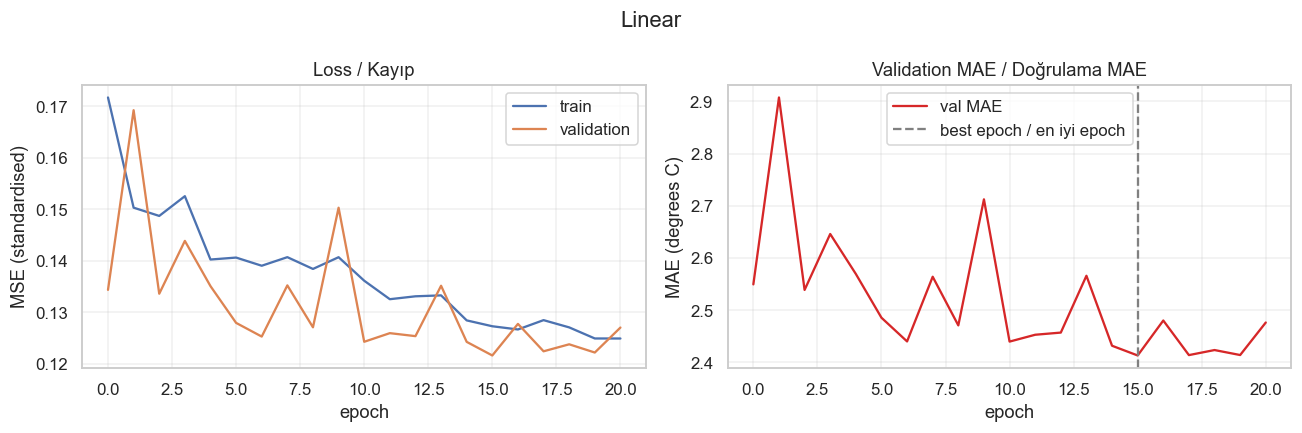

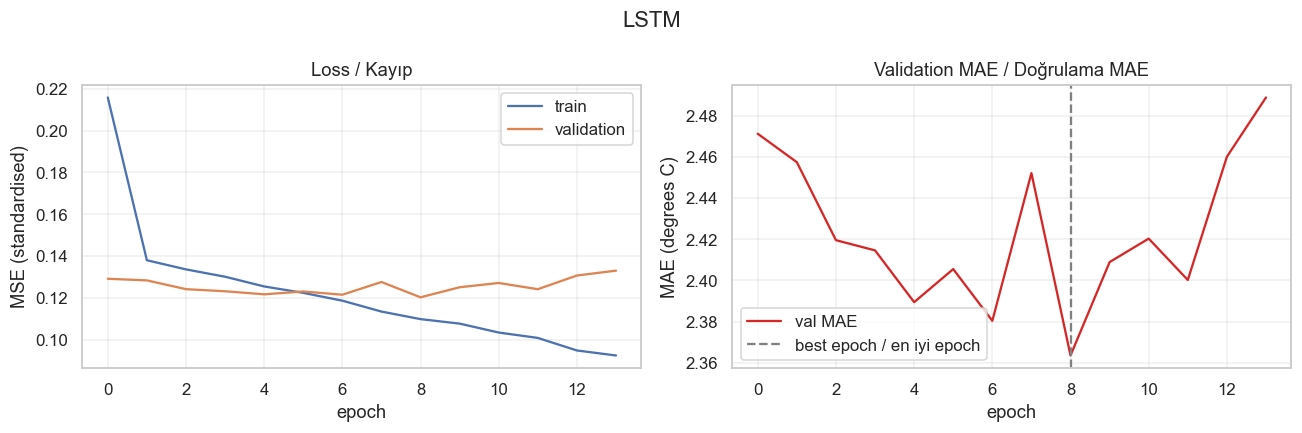

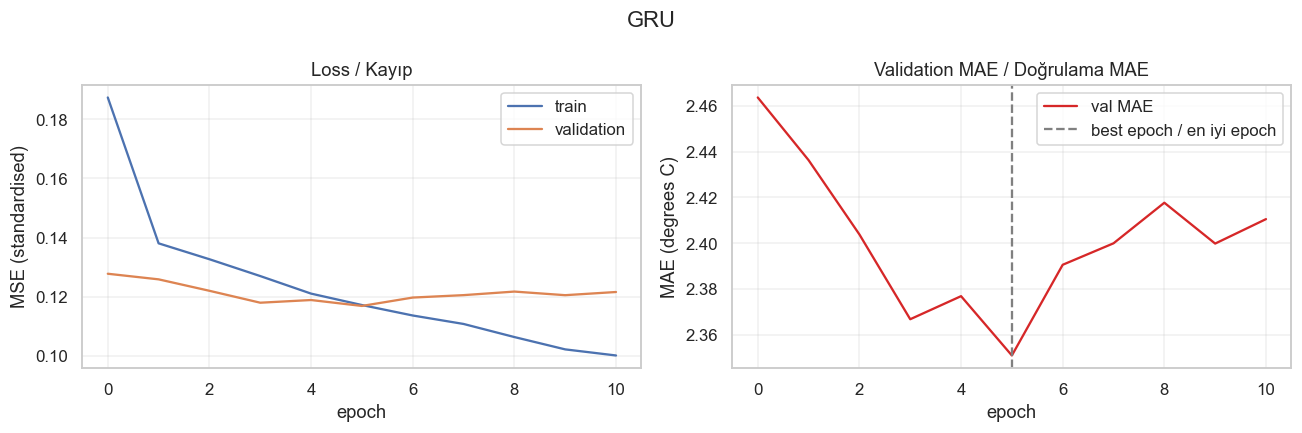

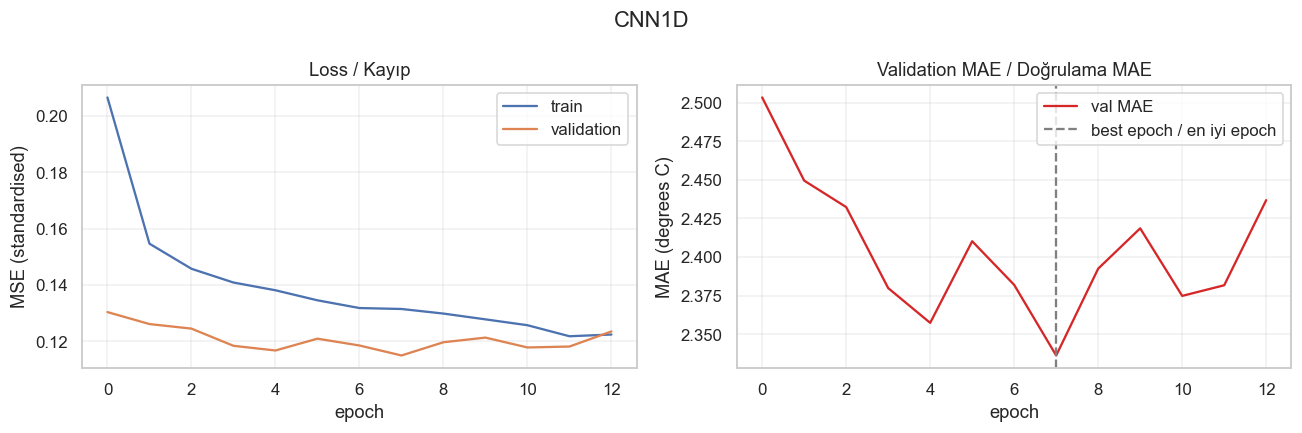

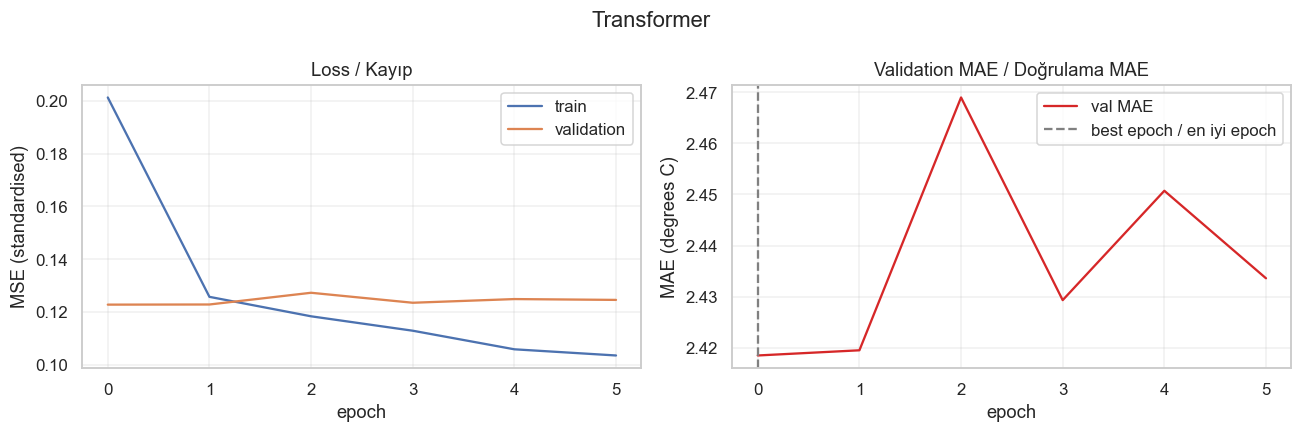

In [15]:
for name, history in histories.items():
    plot_history(history.as_dict(), title=f"{name}", filename=f"history_{name}_full.png")
    plt.show()

## 7. Results — did anything actually beat the baseline? / Sonuçlar — baseline'ı geçen oldu mu?

**EN —** One table, sorted by test MAE, with the honest column: `beats_baseline`.

**TR —** Tek tablo, test MAE'ye göre sıralı, ve dürüst sütun: `beats_baseline`.

In [16]:
table = results_table(results)
display(table.style.format({
    "val_mae": "{:.3f}", "val_rmse": "{:.3f}",
    "test_mae": "{:.3f}", "test_rmse": "{:.3f}",
    "vs_baseline_%": "{:+.1f}",
}))

,val_mae,val_rmse,test_mae,test_rmse,vs_baseline_%,beats_baseline
model,,,,,,
GRU,2.351,3.018,2.345,3.000,-8.9,True
LSTM,2.364,3.061,2.355,3.013,-8.5,True
CNN1D,2.336,2.992,2.367,3.027,-8.0,True
Transformer,2.419,3.093,2.450,3.107,-4.8,True
Linear,2.413,3.077,2.565,3.245,-0.4,True
Persistence,2.555,3.299,2.575,3.368,+0.0,False
Climatology,3.651,4.565,3.712,4.686,+44.2,False
TrainMean,5.898,7.125,6.922,8.491,+168.9,False


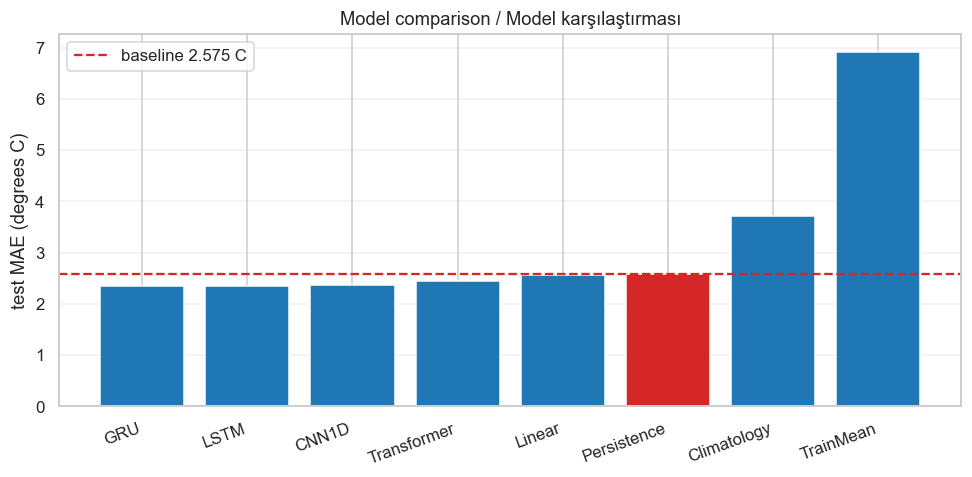

In [17]:
plot_model_comparison(table, filename="model_comparison_full.png")
plt.show()

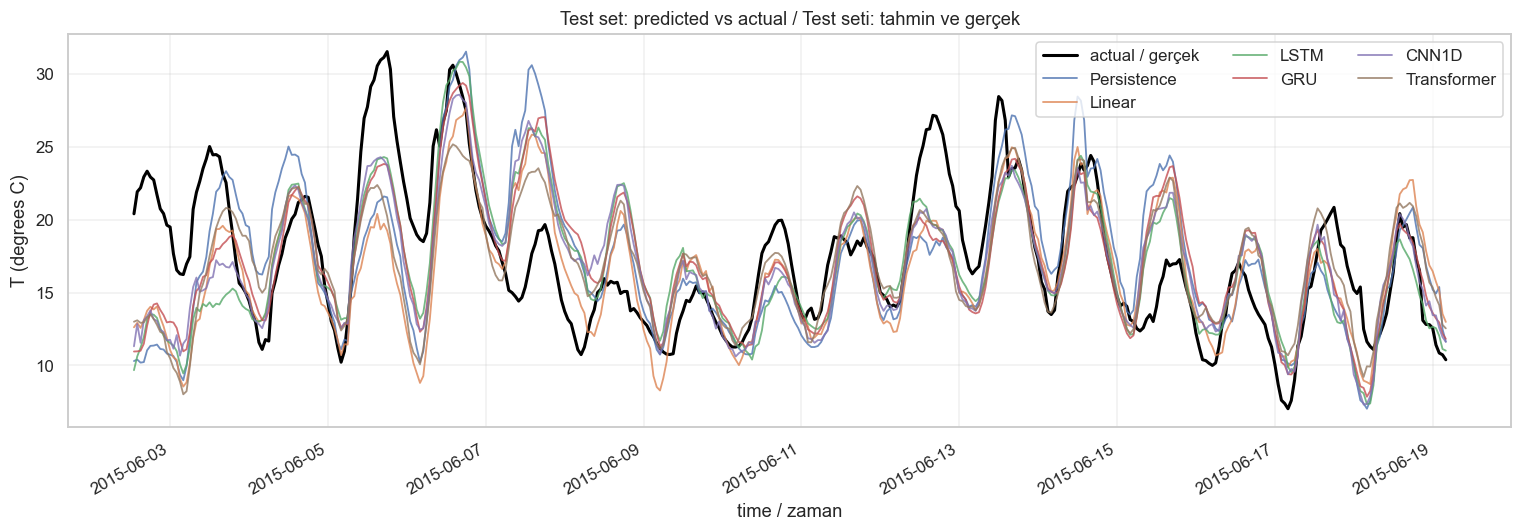

In [18]:
plot_predictions(
    bundle.test.target_times,
    bundle.test.targets_celsius,
    {k: v for k, v in test_predictions.items() if k in ("Persistence", *MODELS_TO_TRAIN)},
    n_points=400,
    title="Test set: predicted vs actual / Test seti: tahmin ve gerçek",
    filename="predictions_full.png",
)
plt.show()

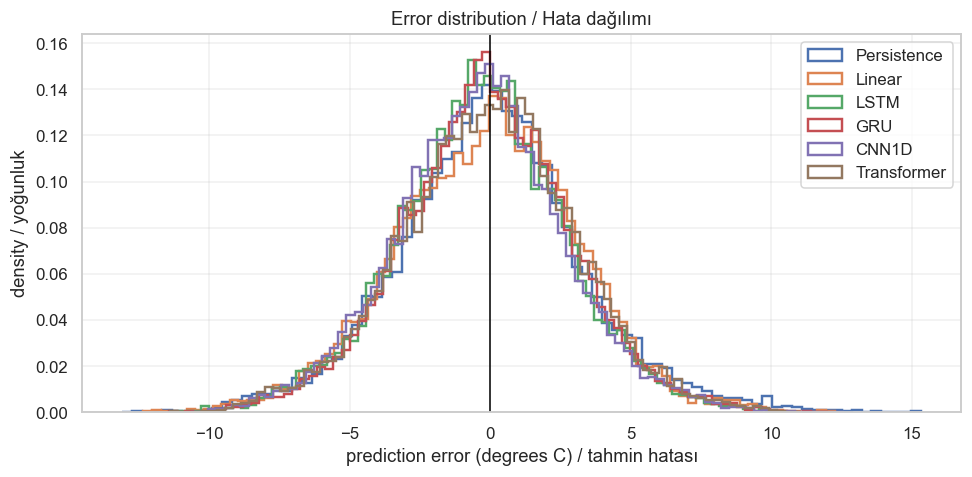

Mean signed error (bias) / Ortalama işaretli hata (yanlılık):
  Persistence    +0.020 °C
  Linear         -0.115 °C
  LSTM           -0.311 °C
  GRU            -0.123 °C
  CNN1D          -0.375 °C
  Transformer    -0.069 °C


In [19]:
errors = {
    name: np.asarray(pred) - bundle.test.targets_celsius
    for name, pred in test_predictions.items()
    if name in ("Persistence", *MODELS_TO_TRAIN)
}
plot_error_distribution(errors, filename="error_distribution_full.png")
plt.show()

print("Mean signed error (bias) / Ortalama işaretli hata (yanlılık):")
for name, err in errors.items():
    print(f"  {name:<14} {err.mean():+.3f} °C")

best trained model / en iyi eğitilmiş model: GRU


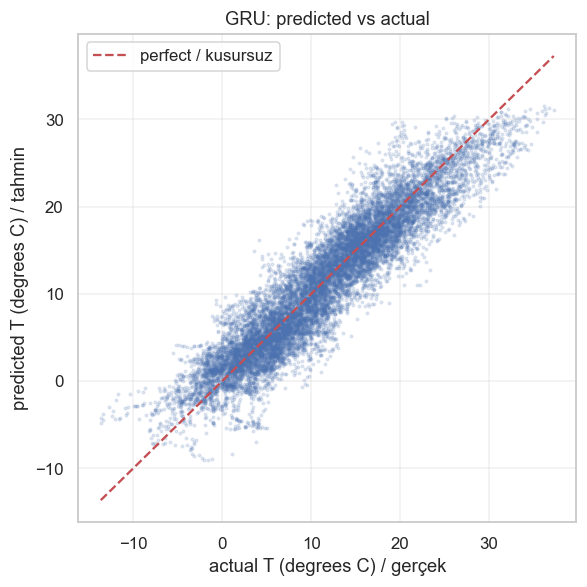

In [20]:
# EN: best TRAINED model, not simply the best row - a baseline could top the
#     table, and "Persistence" is not something I can retrain below.
# TR: en iyi EĞİTİLMİŞ model, sadece en iyi satır değil - tabloyu bir baseline
#     da tepeye çıkabilir ve "Persistence" aşağıda yeniden eğitebileceğim bir şey değil.
best_model_name = next(m for m in table.index if m in MODELS_TO_TRAIN)
print(f"best trained model / en iyi eğitilmiş model: {best_model_name}")

plot_scatter(
    bundle.test.targets_celsius,
    np.asarray(test_predictions[best_model_name]),
    name=f"{best_model_name}: predicted vs actual",
    filename=f"scatter_{best_model_name}_full.png",
)
plt.show()

## 8. Control experiments / Kontrol deneyleri

**EN —** Two questions I want answered rather than assumed:

1. **Did the 13 extra variables earn their place?** I retrain the best architecture with
   temperature as the *only* input and compare.
2. **Do the engineered features help?** Wind direction as a `(Wx, Wy)` vector plus cyclical
   time encodings — cheap to add, and the correlation heatmap suggested the raw variables were
   largely redundant.

**TR —** Varsaymak yerine cevaplamak istediğim iki soru:

1. **13 ek değişken yerini hak etti mi?** En iyi mimariyi girdide *yalnızca* sıcaklıkla
   yeniden eğitip karşılaştırıyorum.
2. **Mühendislik öznitelikleri işe yarıyor mu?** Rüzgâr yönü `(Wx, Wy)` vektörü olarak, artı
   döngüsel zaman kodlamaları — eklemesi ucuz ve korelasyon haritası ham değişkenlerin büyük
   ölçüde fazlalık olduğunu düşündürdü.

In [21]:
control_results = {"Persistence": results["Persistence"]}

# --- 1. univariate control / tek değişkenli kontrol ---
uni_bundle = build_datasets(feature_subset=[config.TARGET_COL])
set_seed(config.SEED)
uni_model = build_model(best_model_name, n_features=uni_bundle.n_features,
                        lookback=config.LOOKBACK_HOURS)
uni_model, uni_history = train_model(uni_model, uni_bundle, device, epochs=config.EPOCHS,
                                     verbose=False)
uni_val, _ = evaluate_model(uni_model, uni_bundle.val, uni_bundle.normalizer, device)
uni_test, _ = evaluate_model(uni_model, uni_bundle.test, uni_bundle.normalizer, device)
control_results[f"{best_model_name} (univariate)"] = {"val": uni_val, "test": uni_test}
print(f"univariate   -> test {uni_test}")

# --- 2. engineered features / mühendislik öznitelikleri ---
eng_bundle = build_datasets(use_engineered_features=True)
set_seed(config.SEED)
eng_model = build_model(best_model_name, n_features=eng_bundle.n_features,
                        lookback=config.LOOKBACK_HOURS)
eng_model, eng_history = train_model(eng_model, eng_bundle, device, epochs=config.EPOCHS,
                                     verbose=False)
eng_val, _ = evaluate_model(eng_model, eng_bundle.val, eng_bundle.normalizer, device)
eng_test, _ = evaluate_model(eng_model, eng_bundle.test, eng_bundle.normalizer, device)
control_results[f"{best_model_name} (engineered)"] = {"val": eng_val, "test": eng_test}
print(f"engineered   -> test {eng_test}  ({eng_bundle.n_features} features)")

control_results[f"{best_model_name} (all raw)"] = results[best_model_name]
display(results_table(control_results).style.format("{:.3f}", subset=[
    c for c in ("val_mae", "val_rmse", "test_mae", "test_rmse")
]))

univariate   -> test MAE 2.517 C | RMSE 3.193 C | n=13,667


engineered   -> test MAE 2.260 C | RMSE 2.863 C | n=13,667  (19 features)


,val_mae,val_rmse,test_mae,test_rmse,vs_baseline_%,beats_baseline
model,,,,,,
GRU (engineered),2.263,2.885,2.260,2.863,-12.237182,True
GRU (all raw),2.351,3.018,2.345,3.000,-8.928201,True
GRU (univariate),2.418,3.078,2.517,3.193,-2.253457,True
Persistence,2.555,3.299,2.575,3.368,0.000000,False


## 9. What I actually conclude / Gerçekte vardığım sonuç

**EN —** Fill this in from the numbers above, not from what you hoped would happen.
The questions worth answering honestly:

- Did any model beat persistence on the **test** set, and by how much in degrees?
- Is the margin large enough to matter? A 0.05 °C improvement is not a forecasting system,
  it is noise.
- Did the deep models beat the plain **Linear** model? If not, the recurrence and the attention
  bought nothing on this task.
- Where do the models fail — look at the error distribution and the prediction plot. Do they lag
  behind sharp changes? That is the classic failure mode of a model that has learned to copy
  the last value.

**TR —** Bunu yukarıdaki sayılara göre doldur; olmasını umduğun şeye göre değil.
Dürüstçe cevaplanmaya değer sorular:

- Herhangi bir model **test** setinde persistence'ı geçti mi, derece cinsinden ne kadar?
- Fark önemsenecek kadar büyük mü? 0.05 °C'lik bir iyileşme tahmin sistemi değil, gürültüdür.
- Derin modeller düz **Linear** modeli geçti mi? Geçmediyse, özyineleme ve dikkat bu görevde
  hiçbir şey kazandırmamış demektir.
- Modeller nerede başarısız oluyor — hata dağılımına ve tahmin grafiğine bak. Keskin
  değişimlerin gerisinde mi kalıyorlar? Bu, son değeri kopyalamayı öğrenmiş bir modelin klasik
  başarısızlık biçimidir.

In [22]:
print("=" * 70)
print("FINAL SCOREBOARD / NİHAİ TABLO")
print("=" * 70)
print(table.to_string(float_format=lambda v: f"{v:.3f}"))

winners = table[table["beats_baseline"] == True]  # noqa: E712
print()
if len(winners):
    best = winners.index[0]
    print(f"{len(winners)} model(s) beat persistence.")
    print(f"Best: {best} at {table.loc[best, 'test_mae']:.3f} °C test MAE "
          f"vs {BASELINE_MAE:.3f} °C baseline "
          f"({-table.loc[best, 'vs_baseline_%']:.1f}% better).")
else:
    print("No model beat the persistence baseline on the test set.")
    print("Bu bir hata değil, bir sonuç: öyle raporla.")

FINAL SCOREBOARD / NİHAİ TABLO
             val_mae  val_rmse  test_mae  test_rmse  vs_baseline_%  beats_baseline
model                                                                             
GRU            2.351     3.018     2.345      3.000         -8.928            True
LSTM           2.364     3.061     2.355      3.013         -8.522            True
CNN1D          2.336     2.992     2.367      3.027         -8.048            True
Transformer    2.419     3.093     2.450      3.107         -4.824            True
Linear         2.413     3.077     2.565      3.245         -0.393            True
Persistence    2.555     3.299     2.575      3.368          0.000           False
Climatology    3.651     4.565     3.712      4.686         44.184           False
TrainMean      5.898     7.125     6.922      8.491        168.853           False

5 model(s) beat persistence.
Best: GRU at 2.345 °C test MAE vs 2.575 °C baseline (8.9% better).
